# Baseline Methods - Anomaly Detection

---
## Section 1 - Setup

In [2]:
%pip install -q -r requirements.txt


[notice] A new release of pip is available: 25.2 -> 26.1.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [3]:
# ── Datasets ──────────────────────────────────────────────────────────────────
DATASETS = {
    "SKAB": {"npy_dir": "npy_skab", "window_size": 30, "n_features": 8},
    "NAB":  {"npy_dir": "npy_nab",  "window_size": 50, "n_features": 1},
}

# ── Dense AE training ─────────────────────────────────────────────────────────
EPOCHS        = 50
BATCH_SIZE    = 256
LR            = 1e-3
LATENT_DIM    = 32
PATIENCE      = 5            # early-stopping patience

# ── Evaluation ────────────────────────────────────────────────────────────────
THRESHOLD_PCT = 95           # val-set percentile used as anomaly threshold

# ── Misc ──────────────────────────────────────────────────────────────────────
SEED         = 42
USE_WANDB    = True         # set True and wandb.login() before enabling
OUTPUT_DIR   = "outputs"
MODELS_DIR   = "models"
RESULTS_FILE = f"{OUTPUT_DIR}/baseline_results.json"

In [4]:
import os
import json
import warnings
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.ensemble import IsolationForest
from sklearn.metrics import (
    average_precision_score,
    roc_auc_score,
    f1_score,
    precision_recall_curve,
)

warnings.filterwarnings("ignore")
matplotlib.rcParams.update({"figure.dpi": 120, "font.size": 10})
np.random.seed(SEED)
torch.manual_seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device : {device}")

os.makedirs(OUTPUT_DIR, exist_ok=True)
os.makedirs(MODELS_DIR, exist_ok=True)

if USE_WANDB:
    import wandb

print("Imports OK")

Device : cpu
Imports OK


In [5]:
# ── Metrics ───────────────────────────────────────────────────────────────────
def compute_metrics(y_true, test_scores, val_scores=None,
                    threshold_pct=THRESHOLD_PCT):
    """Return AUC-PR (primary), AUROC, F1 at val-set percentile threshold."""
    auc_pr = float(average_precision_score(y_true, test_scores))
    auroc  = float(roc_auc_score(y_true, test_scores))
    ref    = val_scores if val_scores is not None else test_scores
    thr    = float(np.percentile(ref, threshold_pct))
    f1     = float(f1_score(y_true, (test_scores >= thr).astype(int),
                            zero_division=0))
    return {"auc_pr": round(auc_pr, 4), "auroc": round(auroc, 4),
            "f1": round(f1, 4), "threshold": thr}


# ── Plot helpers ──────────────────────────────────────────────────────────────
METHOD_COLORS = {
    "B1_zscore":    "#e07b39",
    "B2_isoforest": "#5b8db8",
    "B3_denseae":   "#6aaa5f",
}
METHOD_LABELS = {
    "B1_zscore":    "B1 - Z-score",
    "B2_isoforest": "B2 - Isolation Forest",
    "B3_denseae":   "B3 - Dense AE (det.)",
}


def plot_pr_curves(results_ds, y_test, dataset_name):
    """Overlay PR curves for all three baselines on one dataset."""
    fig, ax = plt.subplots(figsize=(6, 5))
    for key, res in results_ds.items():
        prec, rec, _ = precision_recall_curve(y_test, res["scores"])
        ap = res["metrics"]["auc_pr"]
        ax.plot(rec, prec, lw=1.8, color=METHOD_COLORS[key],
                label=f"{METHOD_LABELS[key]}  AP={ap:.3f}")
    ax.set_xlabel("Recall")
    ax.set_ylabel("Precision")
    ax.set_xlim(0, 1); ax.set_ylim(0, 1)
    ax.set_title(f"Precision-Recall Curves - {dataset_name}")
    ax.legend(fontsize=8)
    plt.tight_layout()
    path = f"{OUTPUT_DIR}/baselines_pr_{dataset_name.lower()}.png"
    plt.savefig(path, bbox_inches="tight")
    plt.show()
    print(f"Saved {path}")


def plot_score_distributions(results_ds, y_test, dataset_name):
    """Score histograms split by normal / anomaly for each baseline."""
    n = len(results_ds)
    fig, axes = plt.subplots(1, n, figsize=(5 * n, 4))
    if n == 1:
        axes = [axes]
    for ax, (key, res) in zip(axes, results_ds.items()):
        s = res["scores"]
        ax.hist(s[y_test == 0], bins=60, alpha=0.6, density=True,
                color="steelblue", label="Normal")
        ax.hist(s[y_test == 1], bins=60, alpha=0.6, density=True,
                color="tomato",   label="Anomaly")
        ax.axvline(res["metrics"]["threshold"], color="black", ls="--", lw=1.2,
                   label=f"Thr ({THRESHOLD_PCT}th pct)")
        ax.set_title(METHOD_LABELS[key], fontsize=9)
        ax.set_xlabel("Anomaly score")
        ax.legend(fontsize=7)
    fig.suptitle(f"Score Distributions - {dataset_name}",
                 fontsize=11, fontweight="bold")
    plt.tight_layout()
    path = f"{OUTPUT_DIR}/baselines_scores_{dataset_name.lower()}.png"
    plt.savefig(path, bbox_inches="tight")
    plt.show()
    print(f"Saved {path}")

In [6]:
def load_npy(npy_dir):
    """Load pre-processed npy arrays. Returns None if the directory is missing."""
    if not os.path.isdir(npy_dir):
        print(f"  WARNING: '{npy_dir}' not found - skipping.")
        return None
    arrays = {}
    for name in ["X_train", "X_val", "X_test", "y_train", "y_val", "y_test"]:
        path = os.path.join(npy_dir, f"{name}.npy")
        if not os.path.exists(path):
            print(f"  WARNING: {path} missing - skipping dataset.")
            return None
        arrays[name] = np.load(path)
    print(f"  Loaded from '{npy_dir}':")
    for k, v in arrays.items():
        print(f"    {k}: {v.shape}  dtype={v.dtype}")
    return arrays


data = {}
for ds_name, cfg in DATASETS.items():
    print(f"\n{'='*45}\n{ds_name}")
    arr = load_npy(cfg["npy_dir"])
    if arr is not None:
        data[ds_name] = arr

print(f"\nDatasets ready: {list(data.keys())}")


SKAB
  Loaded from 'npy_skab':
    X_train: (23588, 30, 8)  dtype=float32
    X_val: (3345, 30, 8)  dtype=float32
    X_test: (19786, 30, 8)  dtype=float32
    y_train: (23588,)  dtype=int8
    y_val: (3345,)  dtype=int8
    y_test: (19786,)  dtype=int8

NAB
  Loaded from 'npy_nab':
    X_train: (229577, 50, 1)  dtype=float32
    X_val: (30354, 50, 1)  dtype=float32
    X_test: (97101, 50, 1)  dtype=float32
    y_train: (229577,)  dtype=int8
    y_val: (30354,)  dtype=int8
    y_test: (97101,)  dtype=int8

Datasets ready: ['SKAB', 'NAB']


---
## Section 2 - B1: Rolling Z-score

In [7]:
def run_zscore(arr):
    """Z-score baseline. Anomaly score = mean |z| across all timesteps and features."""
    X_train, X_val  = arr["X_train"], arr["X_val"]
    X_test,  y_test = arr["X_test"],  arr["y_test"]

    # per-feature statistics from training windows
    flat  = X_train.reshape(-1, X_train.shape[-1])   # (n_timesteps_total, n_features)
    mu    = flat.mean(axis=0)
    sigma = flat.std(axis=0) + 1e-8

    def score(X):
        z = np.abs((X - mu) / sigma)       # (n_windows, ws, n_features)
        return z.mean(axis=(1, 2))         # (n_windows,)

    val_scores  = score(X_val)
    test_scores = score(X_test)
    metrics     = compute_metrics(y_test, test_scores, val_scores)
    return val_scores, test_scores, metrics


zscore_results = {}
for ds_name, arr in data.items():
    print(f"\n{ds_name} - Z-score")
    vs, ts, m = run_zscore(arr)
    zscore_results[ds_name] = {"scores": ts, "val_scores": vs, "metrics": m}
    print(f"  AUC-PR={m['auc_pr']:.4f}  AUROC={m['auroc']:.4f}"
          f"  F1={m['f1']:.4f}  threshold={m['threshold']:.5f}")


SKAB - Z-score
  AUC-PR=0.6455  AUROC=0.3100  F1=0.3451  threshold=1.55521

NAB - Z-score
  AUC-PR=0.3495  AUROC=0.4878  F1=0.1041  threshold=1.84580


---
## Section 3 - B2: Isolation Forest

In [8]:
def run_isoforest(arr):
    """Isolation Forest baseline."""
    X_train, X_val  = arr["X_train"], arr["X_val"]
    X_test,  y_test = arr["X_test"],  arr["y_test"]

    X_tr = X_train.reshape(len(X_train), -1).astype(np.float32)
    X_va = X_val.reshape(len(X_val),   -1).astype(np.float32)
    X_te = X_test.reshape(len(X_test),  -1).astype(np.float32)

    iso = IsolationForest(n_estimators=100, contamination="auto",
                          random_state=SEED, n_jobs=-1)
    iso.fit(X_tr)

    # negate so higher score = more anomalous (consistent with other methods)
    val_scores  = -iso.score_samples(X_va)
    test_scores = -iso.score_samples(X_te)
    metrics     = compute_metrics(y_test, test_scores, val_scores)
    return val_scores, test_scores, metrics


isoforest_results = {}
for ds_name, arr in data.items():
    print(f"\n{ds_name} - Isolation Forest")
    vs, ts, m = run_isoforest(arr)
    isoforest_results[ds_name] = {"scores": ts, "val_scores": vs, "metrics": m}
    print(f"  AUC-PR={m['auc_pr']:.4f}  AUROC={m['auroc']:.4f}"
          f"  F1={m['f1']:.4f}  threshold={m['threshold']:.5f}")


SKAB - Isolation Forest
  AUC-PR=0.7147  AUROC=0.4310  F1=0.4631  threshold=0.55525

NAB - Isolation Forest
  AUC-PR=0.3824  AUROC=0.5486  F1=0.1175  threshold=0.59542


---
## Section 4 - B3: Dense Autoencoder (deterministic)

In [9]:
class DenseAE(nn.Module):
    """Dense autoencoder with configurable dropout.

    dropout_p=0.0  + model.eval()   → deterministic  (B3)
    dropout_p>0.0  + model.train()  → MC Dropout      (M1, notebook 04)
    """

    def __init__(self, input_dim: int, latent_dim: int = 32,
                 dropout_p: float = 0.0):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, 128), nn.ReLU(), nn.Dropout(dropout_p),
            nn.Linear(128, 64),        nn.ReLU(), nn.Dropout(dropout_p),
            nn.Linear(64, latent_dim), nn.ReLU(),
        )
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, 64), nn.ReLU(), nn.Dropout(dropout_p),
            nn.Linear(64, 128),        nn.ReLU(), nn.Dropout(dropout_p),
            nn.Linear(128, input_dim), nn.Sigmoid(),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.decoder(self.encoder(x))

In [10]:
def train_ae(model, X_train, X_val, label, wandb_run=None):
    """Train AE with early stopping. Returns (model, train_losses, val_losses)."""
    t_tens = torch.from_numpy(X_train.reshape(len(X_train), -1)).float()
    v_tens = torch.from_numpy(X_val.reshape(len(X_val),   -1)).float()
    t_dl   = DataLoader(TensorDataset(t_tens), batch_size=BATCH_SIZE, shuffle=True)
    v_dl   = DataLoader(TensorDataset(v_tens), batch_size=BATCH_SIZE)

    opt  = torch.optim.Adam(model.parameters(), lr=LR)
    crit = nn.MSELoss()

    best_val, best_state, patience_ctr = float("inf"), None, 0
    train_losses, val_losses = [], []

    for epoch in range(EPOCHS):
        # ── train ──
        model.train()
        ep_loss = 0.0
        for (xb,) in t_dl:
            xb = xb.to(device)
            loss = crit(model(xb), xb)
            opt.zero_grad(); loss.backward(); opt.step()
            ep_loss += loss.item() * len(xb)
        tl = ep_loss / len(t_tens)

        # ── val ──
        model.eval()
        with torch.no_grad():
            vl = sum(
                crit(model(xb.to(device)), xb.to(device)).item() * len(xb)
                for (xb,) in v_dl
            ) / len(v_tens)

        train_losses.append(tl)
        val_losses.append(vl)

        if (epoch + 1) % 10 == 0 or epoch == 0:
            print(f"    epoch {epoch+1:3d}/{EPOCHS}  "
                  f"train={tl:.5f}  val={vl:.5f}")

        if USE_WANDB and wandb_run:
            wandb_run.log({"train_loss": tl, "val_loss": vl,
                           "epoch": epoch, "label": label})

        # ── early stopping ──
        if vl < best_val - 1e-6:
            best_val     = vl
            best_state   = {k: v.clone() for k, v in model.state_dict().items()}
            patience_ctr = 0
        else:
            patience_ctr += 1
            if patience_ctr >= PATIENCE:
                print(f"    Early stopping at epoch {epoch + 1}")
                break

    model.load_state_dict(best_state)
    return model, train_losses, val_losses


def ae_scores(model, X, batch_size=512):
    """Per-window mean squared reconstruction error."""
    model.eval()
    dl  = DataLoader(
        TensorDataset(torch.from_numpy(X.reshape(len(X), -1)).float()),
        batch_size=batch_size)
    out = []
    with torch.no_grad():
        for (xb,) in dl:
            xb  = xb.to(device)
            err = ((xb - model(xb)) ** 2).mean(dim=1)
            out.append(err.cpu().numpy())
    return np.concatenate(out)

wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /Users/ayyoubsoullami/.netrc.



SKAB - Dense AE (deterministic, dropout_p=0)
  input_dim=240  X_train=(23588, 30, 8)  X_val=(3345, 30, 8)


wandb: Currently logged in as: soullamiayyoub (soullamiayyoub-university-of-miskolc) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


    epoch   1/50  train=0.03615  val=0.01514
    epoch  10/50  train=0.00909  val=0.00773
    epoch  20/50  train=0.00875  val=0.00715
    epoch  30/50  train=0.00836  val=0.00697
    epoch  40/50  train=0.00788  val=0.00646
    epoch  50/50  train=0.00752  val=0.00622
  Saved → models/dense_ae_b3_skab.pt

  AUC-PR=0.7998  AUROC=0.6180  F1=0.3893  threshold=0.008533


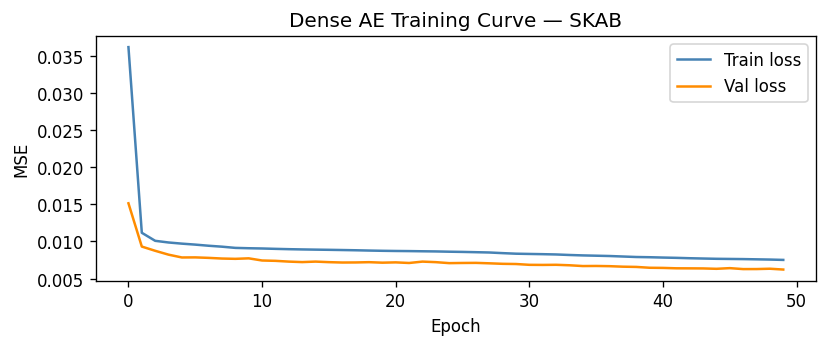

wandb: ERROR The nbformat package was not found. It is required to save notebook history.


epoch,▁▁▁▁▂▂▂▂▂▃▃▃▃▃▃▄▄▄▄▄▅▅▅▅▅▅▆▆▆▆▆▇▇▇▇▇▇███
train_loss,█▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
val_loss,█▃▃▃▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▁▂▁▁▁▁▁▁▁▁▁▁▁▁▁
epoch,49
label,B3_SKAB
train_loss,0.00752
val_loss,0.00622



NAB - Dense AE (deterministic, dropout_p=0)
  input_dim=50  X_train=(229577, 50, 1)  X_val=(30354, 50, 1)


    epoch   1/50  train=0.01628  val=0.00849
    epoch  10/50  train=0.00308  val=0.00292
    epoch  20/50  train=0.00242  val=0.00227
    epoch  30/50  train=0.00221  val=0.00208
    epoch  40/50  train=0.00214  val=0.00200
    epoch  50/50  train=0.00211  val=0.00197
  Saved → models/dense_ae_b3_nab.pt

  AUC-PR=0.4665  AUROC=0.5993  F1=0.3173  threshold=0.007665


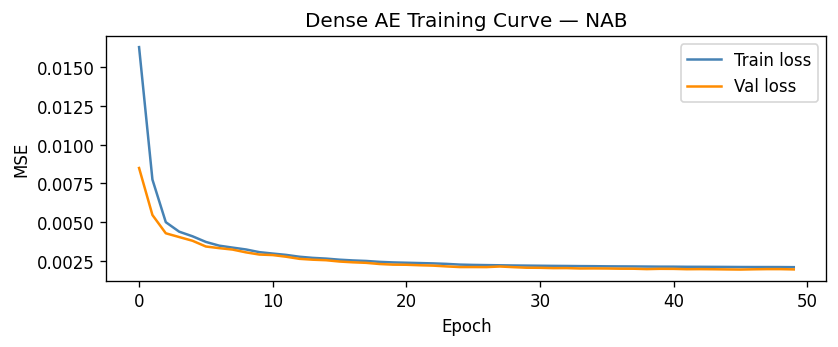

wandb: ERROR The nbformat package was not found. It is required to save notebook history.


epoch,▁▁▁▁▂▂▂▂▂▂▃▃▃▃▃▄▄▄▄▄▄▅▅▅▅▅▅▆▆▆▆▆▆▇▇▇▇███
train_loss,█▄▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
val_loss,█▅▃▃▃▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
epoch,49
label,B3_NAB
train_loss,0.00211
val_loss,0.00197


In [11]:
denseae_results = {}

for ds_name, arr in data.items():
    print(f"\n{'='*55}")
    print(f"{ds_name} - Dense AE (deterministic, dropout_p=0)")

    X_train, X_val  = arr["X_train"], arr["X_val"]
    X_test,  y_test = arr["X_test"],  arr["y_test"]
    input_dim = X_train.shape[1] * X_train.shape[2]   # window_size × n_features
    print(f"  input_dim={input_dim}  "
          f"X_train={X_train.shape}  X_val={X_val.shape}")

    wandb_run = None
    if USE_WANDB:
        wandb_run = wandb.init(
            project="iot-ad-baselines",
            name=f"B3_DenseAE_{ds_name}",
            config={"epochs": EPOCHS, "lr": LR, "latent_dim": LATENT_DIM,
                    "dropout_p": 0.0, "dataset": ds_name})

    model = DenseAE(input_dim, latent_dim=LATENT_DIM, dropout_p=0.0).to(device)
    model, train_losses, val_losses = train_ae(
        model, X_train, X_val, label=f"B3_{ds_name}", wandb_run=wandb_run)

    # ── save checkpoint ──
    ckpt = os.path.join(MODELS_DIR, f"dense_ae_b3_{ds_name.lower()}.pt")
    torch.save(model.state_dict(), ckpt)
    print(f"  Saved → {ckpt}")

    # ── inference ──
    val_scores  = ae_scores(model, X_val)
    test_scores = ae_scores(model, X_test)
    metrics     = compute_metrics(y_test, test_scores, val_scores)

    denseae_results[ds_name] = {
        "scores":       test_scores,
        "val_scores":   val_scores,
        "metrics":      metrics,
        "train_losses": train_losses,
        "val_losses":   val_losses,
    }

    print(f"\n  AUC-PR={metrics['auc_pr']:.4f}  AUROC={metrics['auroc']:.4f}"
          f"  F1={metrics['f1']:.4f}  threshold={metrics['threshold']:.6f}")

    # ── training curve ──
    fig, ax = plt.subplots(figsize=(7, 3))
    ax.plot(train_losses, color="steelblue",  label="Train loss")
    ax.plot(val_losses,   color="darkorange", label="Val loss")
    ax.set_xlabel("Epoch"); ax.set_ylabel("MSE")
    ax.set_title(f"Dense AE Training Curve - {ds_name}")
    ax.legend()
    plt.tight_layout()
    plt.savefig(f"{OUTPUT_DIR}/b3_training_curve_{ds_name.lower()}.png",
                bbox_inches="tight")
    plt.show()

    if USE_WANDB and wandb_run:
        wandb_run.finish()

---
## Section 5 - Results Comparison

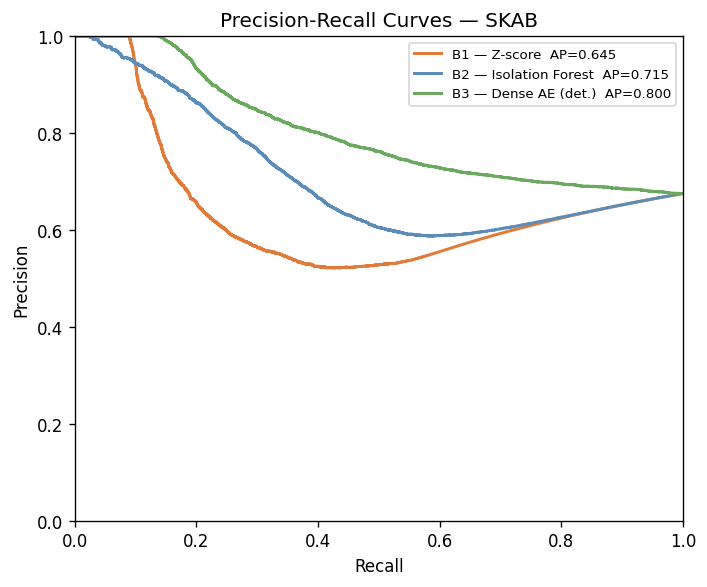

Saved outputs/baselines_pr_skab.png


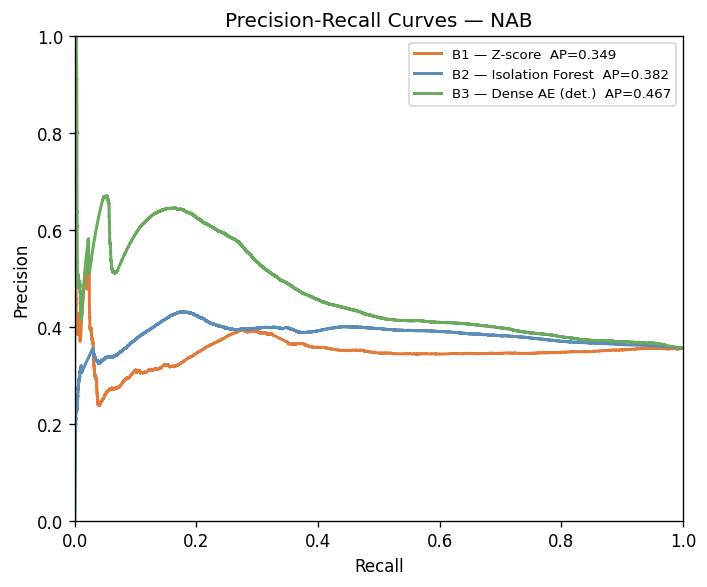

Saved outputs/baselines_pr_nab.png


In [12]:
for ds_name in data:
    plot_pr_curves(
        {
            "B1_zscore":    zscore_results[ds_name],
            "B2_isoforest": isoforest_results[ds_name],
            "B3_denseae":   denseae_results[ds_name],
        },
        data[ds_name]["y_test"],
        ds_name,
    )

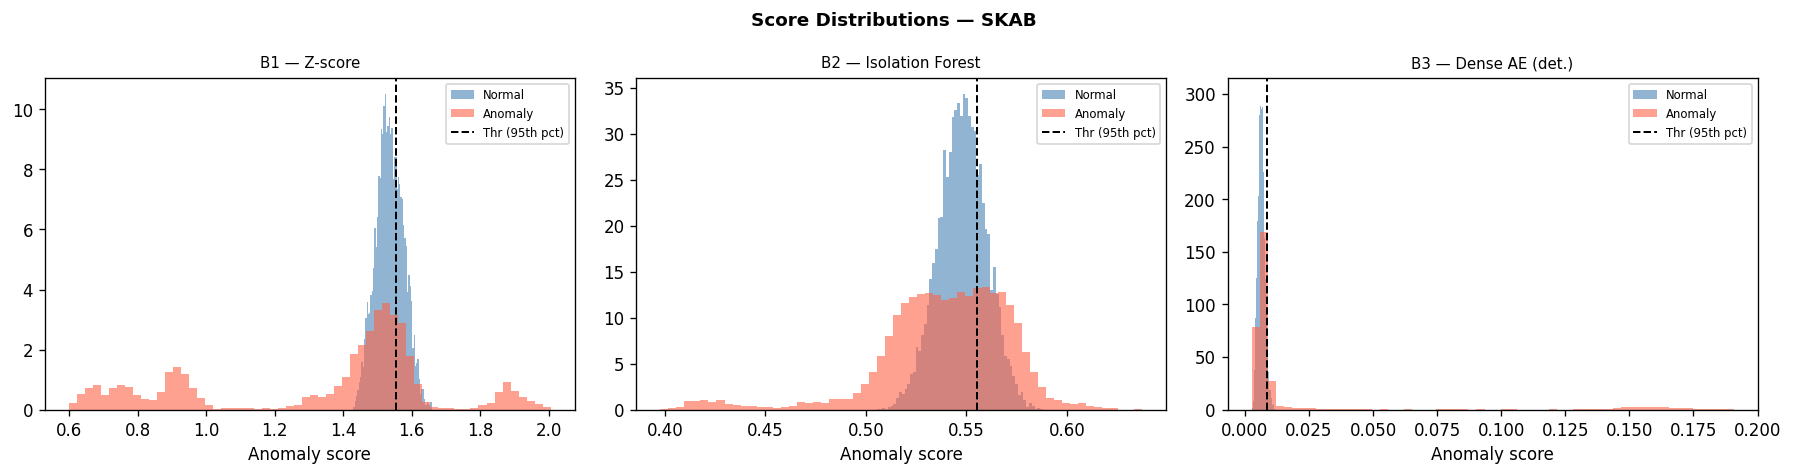

Saved outputs/baselines_scores_skab.png


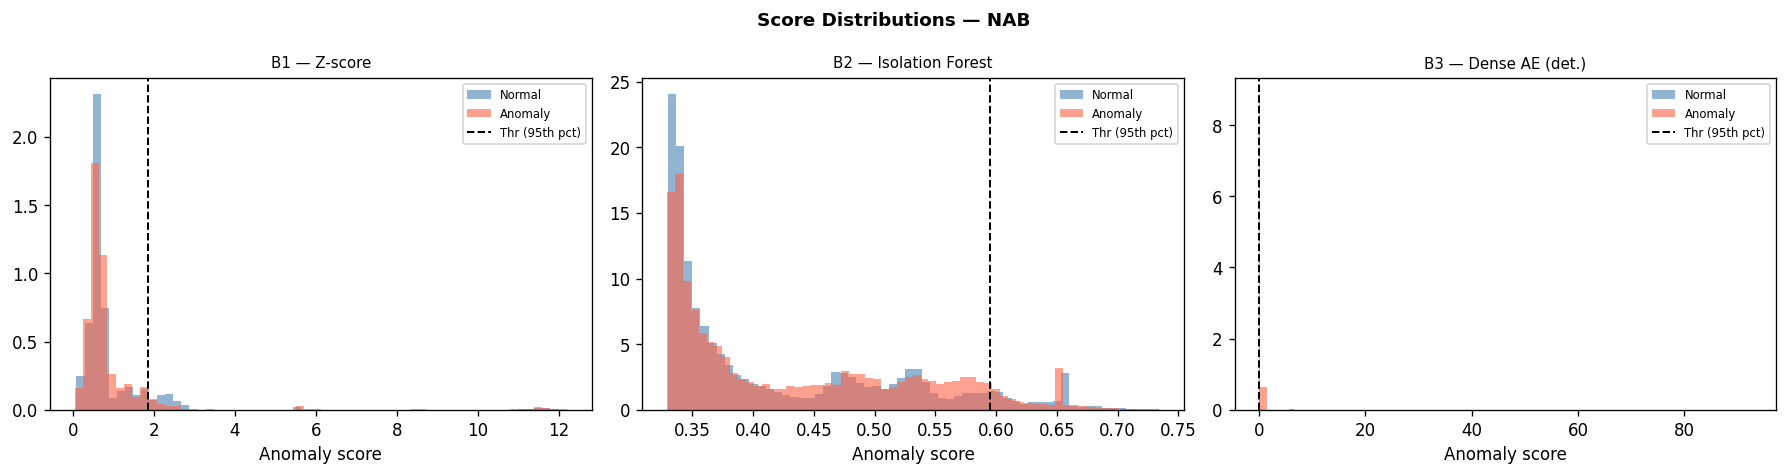

Saved outputs/baselines_scores_nab.png


In [13]:
for ds_name in data:
    plot_score_distributions(
        {
            "B1_zscore":    zscore_results[ds_name],
            "B2_isoforest": isoforest_results[ds_name],
            "B3_denseae":   denseae_results[ds_name],
        },
        data[ds_name]["y_test"],
        ds_name,
    )

In [14]:
rows = []
for ds_name in data:
    src = {
        "B1_zscore":    zscore_results,
        "B2_isoforest": isoforest_results,
        "B3_denseae":   denseae_results,
    }
    for key, label in METHOD_LABELS.items():
        m = src[key][ds_name]["metrics"]
        rows.append({
            "Dataset": ds_name, "Method": label,
            "AUC-PR":  m["auc_pr"],
            "AUROC":   m["auroc"],
            "F1":      m["f1"],
        })

summary_df = pd.DataFrame(rows).set_index(["Dataset", "Method"])

print(summary_df.to_string())
print()

display(
    summary_df.style
    .background_gradient(subset=["AUC-PR"], cmap="Greens")
    .background_gradient(subset=["AUROC"],  cmap="Blues")
    .background_gradient(subset=["F1"],     cmap="Oranges")
    .format("{:.4f}")
)

                               AUC-PR   AUROC      F1
Dataset Method                                       
SKAB    B1 - Z-score           0.6455  0.3100  0.3451
        B2 - Isolation Forest  0.7147  0.4310  0.4631
        B3 - Dense AE (det.)   0.7998  0.6180  0.3893
NAB     B1 - Z-score           0.3495  0.4878  0.1041
        B2 - Isolation Forest  0.3824  0.5486  0.1175
        B3 - Dense AE (det.)   0.4665  0.5993  0.3173



In [15]:
# Scores are numpy arrays - convert to list for JSON serialisation
save = {}
for ds_name in data:
    save[ds_name] = {
        "B1_zscore": {
            "metrics": zscore_results[ds_name]["metrics"],
        },
        "B2_isoforest": {
            "metrics": isoforest_results[ds_name]["metrics"],
        },
        "B3_denseae": {
            "metrics":      denseae_results[ds_name]["metrics"],
            "train_losses": denseae_results[ds_name]["train_losses"],
            "val_losses":   denseae_results[ds_name]["val_losses"],
        },
    }

with open(RESULTS_FILE, "w") as f:
    json.dump(save, f, indent=2)

print(f"Results saved → {RESULTS_FILE}")
print(json.dumps(save, indent=2))

Results saved → outputs/baseline_results.json
{
  "SKAB": {
    "B1_zscore": {
      "metrics": {
        "auc_pr": 0.6455,
        "auroc": 0.31,
        "f1": 0.3451,
        "threshold": 1.555209994316101
      }
    },
    "B2_isoforest": {
      "metrics": {
        "auc_pr": 0.7147,
        "auroc": 0.431,
        "f1": 0.4631,
        "threshold": 0.5552530350299686
      }
    },
    "B3_denseae": {
      "metrics": {
        "auc_pr": 0.7998,
        "auroc": 0.618,
        "f1": 0.3893,
        "threshold": 0.008533162996172905
      },
      "train_losses": [
        0.03615021729048696,
        0.011170714447830408,
        0.010088869557669047,
        0.009864272112277922,
        0.009708241642795015,
        0.00957725146207033,
        0.009425541198385536,
        0.00929935817297675,
        0.009137016285494492,
        0.009089888620578992,
        0.009057087026667864,
        0.009006886133551092,
        0.008963483794626591,
        0.008930081275603024,
      

In [16]:
print("=" * 62)
print("  BASELINE RESULTS - FINAL SUMMARY")
print("=" * 62)
for ds_name in data:
    print(f"\n  {ds_name}")
    print(f"  {'Method':<32} {'AUC-PR':>8} {'AUROC':>8} {'F1':>8}")
    print(f"  {'-'*58}")
    src = {
        "B1_zscore":    zscore_results,
        "B2_isoforest": isoforest_results,
        "B3_denseae":   denseae_results,
    }
    for key, label in METHOD_LABELS.items():
        m = src[key][ds_name]["metrics"]
        print(f"  {label:<32} {m['auc_pr']:>8.4f} {m['auroc']:>8.4f} {m['f1']:>8.4f}")
print("=" * 62)
print(f"\nAll plots  → {OUTPUT_DIR}/")
print(f"All models → {MODELS_DIR}/")
print(f"Results    → {RESULTS_FILE}")

  BASELINE RESULTS - FINAL SUMMARY

  SKAB
  Method                             AUC-PR    AUROC       F1
  ----------------------------------------------------------
  B1 - Z-score                       0.6455   0.3100   0.3451
  B2 - Isolation Forest              0.7147   0.4310   0.4631
  B3 - Dense AE (det.)               0.7998   0.6180   0.3893

  NAB
  Method                             AUC-PR    AUROC       F1
  ----------------------------------------------------------
  B1 - Z-score                       0.3495   0.4878   0.1041
  B2 - Isolation Forest              0.3824   0.5486   0.1175
  B3 - Dense AE (det.)               0.4665   0.5993   0.3173

All plots  → outputs/
All models → models/
Results    → outputs/baseline_results.json
